# Embedding-Based Selection of Stimuli

This notebook develops a process to select a diverse subset of items from the dataset. Oversampling has given more items than needed for each group, so a method is required to narrow down to 10 per group without clustering on similar topics. The guiding idea is to balance coverage across different themes while keeping the process reproducible.

An embedding is a numerical representation of text. Each sentence is mapped into a vector in a high-dimensional space, where distances between vectors reflect how similar or different the texts are in meaning. By using embeddings, the selection process can measure diversity directly instead of relying on surface features.

The workflow will:
- Inspect the dataset to confirm structure
- Generate embeddings with SBERT
- Explore two strategies for selecting subsets of 10 items with high diversity
- Compare results and finalize the chosen subsets

All code uses a fixed random seed to ensure reproducibility. Outputs will include saved embeddings, selected subsets, and scripts that mirror the notebook for later use.


### Dataset overview

The dataset contains text stimuli with information about their domain, agreement level, and annotations. Each row is a single item with both the original and cleaned text.

Two filters are applied before selection:
- `domain_correct = 1` keeps only items judged to belong in the correct domain.
- `valid = 1` keeps only items that are coherent sentences.

The columns kept for this process are chosen for specific reasons:
- `rot_clean`: the cleaned text field, used for embeddings. The original text and other fragments (such as `action` or `situation`) are not used because they either duplicate information or only capture part of the statement.
- `ssl_domain`: the domain label (moral, conventional, personal, etc.). This is required to ensure balance across categories.
- `agreement_condition`: the agreement grouping (low, high, etc.). This defines part of the selection key.
- `agreement_label`: percentage-based label for agreement, which adds clarity when reviewing subsets.

Other columns such as `rot`, `action`, `situation`, and annotation scores are not included in this step because they are either redundant, too narrow, or not needed for embedding-based selection. The focus is on full statements and their grouping categories.


In [1]:
import pandas as pd

# Load dataset
file_path = "../data/clean/ssl_stimuli_final_unannot.csv"
df = pd.read_csv(file_path)

# Apply filters
df = df[(df["domain_correct"] == 1) & (df["valid"] == 1)]
df = df.reset_index(drop=True)

# Preview relevant columns
df[["rot_clean", "ssl_domain", "agreement_condition", "agreement_label"]].head(10)


,rot_clean,ssl_domain,agreement_condition,agreement_label
0,It's wrong to not have someone in life to teac...,moral,low_agreement,5-25%
1,It's okay to use your body to make a living.,moral,low_agreement,5-25%
2,It's wrong to date someone that isn't ready fo...,moral,low_agreement,5-25%
3,It's wrong to watch rated R movies if you're u...,moral,low_agreement,5-25%
4,Parents should involve children in their probl...,moral,low_agreement,5-25%
5,It's fine to hook up with anyone you find attr...,moral,low_agreement,5-25%
6,It's wrong to relay a message you have taken f...,moral,low_agreement,<1%
7,You shouldn't tell your kids what to do.,moral,low_agreement,5-25%
8,It's expected you get into a fight if you're b...,moral,low_agreement,5-25%
9,It's selfish to expect your husband to give yo...,moral,low_agreement,5-25%


### Distribution across groups

The table shows how many items are available in each group after filtering. Each group is defined by a domain and an agreement condition. Oversampling is visible because each group has far more than the target of 10 items.

A bar plot gives the same information in a way that is easier to scan at a glance.


,ssl_domain,agreement_condition,count
0,moral,high_agreement,39
1,moral,low_agreement,38
2,moral,medium_agreement,39
3,personal-psychological,high_agreement,36
4,personal-psychological,low_agreement,38
5,personal-psychological,medium_agreement,38
6,societal-conventional,high_agreement,40
7,societal-conventional,low_agreement,37
8,societal-conventional,medium_agreement,40


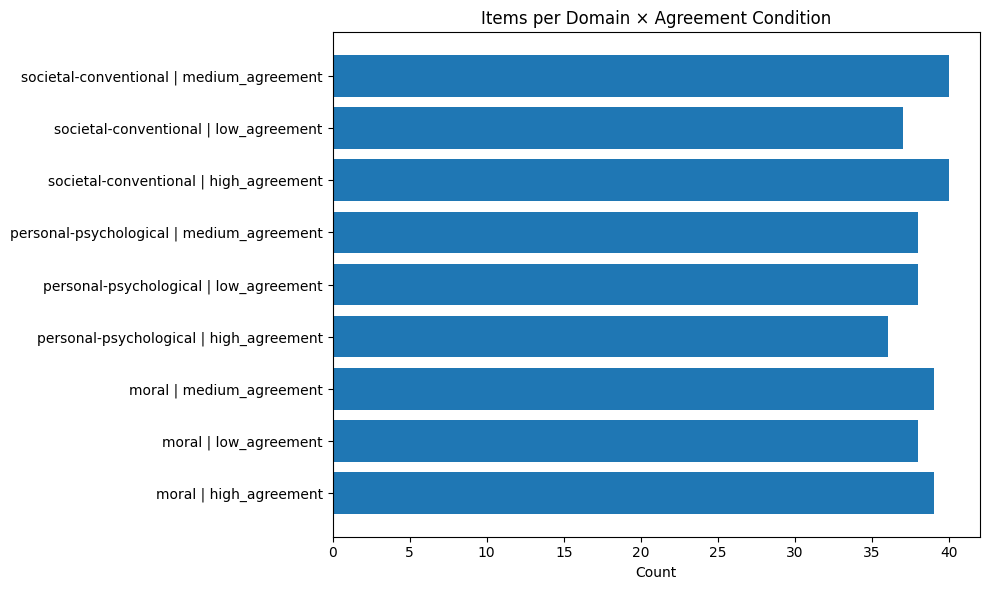

In [2]:
import matplotlib.pyplot as plt

# Table view
group_counts = (
    df.groupby(["ssl_domain", "agreement_condition"])
      .size()
      .reset_index(name="count")
      .sort_values(["ssl_domain", "agreement_condition"])
)
display(group_counts)

# Horizontal bar plot
plt.figure(figsize=(10,6))
plt.barh(
    y=group_counts["ssl_domain"] + " | " + group_counts["agreement_condition"],
    width=group_counts["count"]
)
plt.xlabel("Count")
plt.title("Items per Domain × Agreement Condition")
plt.tight_layout()
plt.show()


### Embedding generation

The cleaned text is converted into embeddings using a pretrained SBERT model. An embedding is a vector of numbers that places the text in a high-dimensional space where distances reflect semantic similarity. This representation allows direct comparison of items based on meaning rather than surface wording.

The model `all-MiniLM-L6-v2` is used here. It produces 384-dimensional embeddings, is lightweight, and runs efficiently while still capturing topic similarity. Larger models such as `all-mpnet-base-v2` or `all-distilroberta-v1` can provide finer distinctions but require more computation. For this task, the balance of speed and quality makes `all-MiniLM-L6-v2` a practical choice.

Embeddings are stored for reuse so the selection strategies can run without recalculating them. A fixed random seed is applied during encoding for reproducibility.


In [3]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load SBERT model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Encode cleaned text with fixed seed for reproducibility
np.random.seed(42)
embeddings = model.encode(df["rot_clean"].tolist(), show_progress_bar=True)

# Save embeddings to file for reuse
np.save("../data/clean/ssl_embeddings.npy", embeddings)

# Quick check on shape
print("Embeddings shape:", embeddings.shape)


Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Embeddings shape: (345, 384)


### Selection strategies

The aim is to choose 10 items per group in a way that maximizes diversity. Two complementary strategies will be explored. Both rely on the embeddings to measure how different items are from each other.

**Random subset evaluation**
Large numbers of random subsets are generated, and for each one the diversity score is calculated using pairwise distances. The subset with the highest diversity is kept.

**Greedy diversity selection**
A starting item is chosen at random. At each step, the item most different from the current set is added. This continues until 10 items are selected.

Comparing these two methods helps confirm whether they arrive at similar diverse subsets or highlight different possibilities.


### Random subset evaluation

This method generates many random subsets of 10 items within each group. A diversity score is calculated for each subset using the pairwise distances between embeddings. The subset with the highest median distance is chosen as the most diverse.


In [4]:
import numpy as np
from sklearn.metrics.pairwise import cosine_distances

def select_random_diverse_subset(embeddings, n_samples=10, n_trials=1000, random_state=42):
    rng = np.random.default_rng(random_state)
    best_subset = None
    best_score = -np.inf

    n_items = embeddings.shape[0]
    for _ in range(n_trials):
        idx = rng.choice(n_items, size=n_samples, replace=False)
        subset = embeddings[idx]
        dists = cosine_distances(subset)
        # Take upper triangle without diagonal
        tri = dists[np.triu_indices_from(dists, k=1)]
        score = np.median(tri)
        if score > best_score:
            best_score = score
            best_subset = idx

    return best_subset, best_score

# Example on one group (moral, low_agreement)
group = df[(df["ssl_domain"] == "moral") & (df["agreement_condition"] == "low_agreement")]
group_embeddings = embeddings[group.index]

subset_idx, subset_score = select_random_diverse_subset(group_embeddings)
selected_items = group.iloc[subset_idx]

print("Diversity score:", subset_score)
selected_items[["rot_clean", "ssl_domain", "agreement_condition", "agreement_label"]]


Diversity score: 0.8632337


,rot_clean,ssl_domain,agreement_condition,agreement_label
6,It's wrong to relay a message you have taken f...,moral,low_agreement,<1%
16,You shouldn't call the cops on people who park...,moral,low_agreement,5-25%
9,It's selfish to expect your husband to give yo...,moral,low_agreement,5-25%
11,It's wrong to have fantasies about dating auti...,moral,low_agreement,<1%
24,It's wrong to delete your confessions.,moral,low_agreement,5-25%
4,Parents should involve children in their probl...,moral,low_agreement,5-25%
19,It is selfish to not want a family.,moral,low_agreement,5-25%
31,It's understandable if you use a customer's de...,moral,low_agreement,5-25%
17,People should be pure until they get married.,moral,low_agreement,5-25%
30,You can't expect your kids to be there for you...,moral,low_agreement,5-25%


### Applying random subset evaluation across groups

The same procedure can be applied to every domain × agreement condition group. A helper function runs the selection method within each group and combines the results into a single dataframe. This produces a consistent set of 10 diverse items per group.


In [5]:
def select_across_groups(df, embeddings, n_samples=10, n_trials=1000, random_state=42):
    results = []
    for (domain, agreement), group in df.groupby(["ssl_domain", "agreement_condition"]):
        group_embeddings = embeddings[group.index]
        subset_idx, subset_score = select_random_diverse_subset(
            group_embeddings, n_samples=n_samples, n_trials=n_trials, random_state=random_state
        )
        selected = group.iloc[subset_idx].copy()
        selected["diversity_score"] = subset_score
        results.append(selected)
    return pd.concat(results, ignore_index=True)

# Run across all groups
selected_random = select_across_groups(df, embeddings)

# Preview
selected_random[["rot_clean", "ssl_domain", "agreement_condition", "agreement_label", "diversity_score"]].head(20)


,rot_clean,ssl_domain,agreement_condition,agreement_label,diversity_score
0,It's bad to do things that are disgusting.,moral,high_agreement,75-90%,0.822058
1,It is rude to tow an elderly persons car out o...,moral,high_agreement,75-90%,0.822058
2,It is understandable to be upset if your signi...,moral,high_agreement,>99%,0.822058
3,It's good to raise awareness for certain medic...,moral,high_agreement,75-90%,0.822058
4,You have the right to tell your parent not to ...,moral,high_agreement,>99%,0.822058
5,It's bad to be a terrorist.,moral,high_agreement,75-90%,0.822058
6,It's wrong to cheat on others.,moral,high_agreement,>99%,0.822058
7,It's good to adopt children with no home.,moral,high_agreement,>99%,0.822058
8,It's bad to cheat on a spouse.,moral,high_agreement,75-90%,0.822058
9,It is good to admit when you are wrong.,moral,high_agreement,75-90%,0.822058


### Interpreting the random subset results

The table shows the 10 items selected from each group. For example, the rows above come from the `moral | high_agreement` and `moral | low_agreement` groups. Every row contains the cleaned text, the domain, the agreement condition, the agreement label, and the diversity score.

Within a group, all 10 rows share the same diversity score. This value reflects the median distance between items in the subset. Higher values mean the items are more spread out in semantic space, so the set covers a wider range of topics. The consistency of the score across rows in a group comes from the fact that it describes the subset as a whole, not individual rows.

What matters here is that each group now has a reduced set of 10 items that are both representative and non-redundant. Oversampling has been resolved in a way that maintains diversity, while still respecting the domain and agreement structure.


The selected subsets are also saved to a CSV file so they can be reused without rerunning the selection process. This creates a permanent record of the diverse items chosen by the random evaluation method.


In [6]:
# Save results to CSV
selected_random.to_csv("../data/clean/ssl_random_selected.csv", index=False)
print("Saved to ../data/clean/ssl_random_selected.csv")


Saved to ../data/clean/ssl_random_selected.csv


### Greedy diversity selection

A different strategy is to build the subset step by step. The process begins with a single random item. At each step, the item most dissimilar to the current set is added. The comparison is made using distances between embeddings, and the procedure repeats until 10 items are chosen.

This method aims to spread out the selected items in embedding space as widely as possible. Unlike the random subset evaluation, which compares many complete subsets, the greedy method grows one subset iteratively. The results provide a second perspective on diversity and can be compared against the random method for consistency.


In [7]:
from sklearn.metrics.pairwise import cosine_distances
import numpy as np

def select_greedy_diverse_subset(embeddings, n_samples=10, random_state=42):
    rng = np.random.default_rng(random_state)
    n_items = embeddings.shape[0]

    # Start with one random item
    start_idx = rng.integers(0, n_items)
    selected = [start_idx]

    # Iteratively add the most dissimilar item
    while len(selected) < n_samples:
        current_subset = embeddings[selected]
        centroid = current_subset.mean(axis=0, keepdims=True)
        dists = cosine_distances(embeddings, centroid).flatten()
        dists[selected] = -np.inf  # exclude already selected
        next_idx = np.argmax(dists)
        selected.append(next_idx)

    # Compute diversity score for the final subset
    subset = embeddings[selected]
    pairwise = cosine_distances(subset)
    tri = pairwise[np.triu_indices_from(pairwise, k=1)]
    score = np.median(tri)

    return selected, score

# Example on one group (moral, high_agreement)
group = df[(df["ssl_domain"] == "moral") & (df["agreement_condition"] == "high_agreement")]
group_embeddings = embeddings[group.index.to_numpy()]

subset_idx, subset_score = select_greedy_diverse_subset(group_embeddings)
selected_items = group.iloc[subset_idx].copy()

print("Diversity score:", subset_score)
selected_items[["rot_clean", "ssl_domain", "agreement_condition", "agreement_label"]]


Diversity score: 0.8500022


,rot_clean,ssl_domain,agreement_condition,agreement_label
80,It's good to help others.,moral,high_agreement,75-90%
79,It is understandable to be upset if your signi...,moral,high_agreement,>99%
113,You have the right to tell your parent not to ...,moral,high_agreement,>99%
115,It is rude to tow an elderly persons car out o...,moral,high_agreement,75-90%
90,It's bad to be a terrorist.,moral,high_agreement,75-90%
88,You should tell your partner if you're pregnant.,moral,high_agreement,75-90%
77,You shouldn't judge yourself or others based o...,moral,high_agreement,75-90%
95,It's good to raise awareness for certain medic...,moral,high_agreement,75-90%
81,It's wrong to not pay back money you've borrowed.,moral,high_agreement,>99%
104,It's okay to like a celebrity you really admire.,moral,high_agreement,75-90%


### Applying greedy diversity selection across groups

The greedy method can be scaled across all domain × agreement condition groups in the same way as the random method. For each group, 10 items are selected iteratively to maximize distance from the current set. The results are collected into a single dataframe, with the diversity score recorded for each group.


In [8]:
def select_across_groups_greedy(df, embeddings, n_samples=10, random_state=42):
    results = []
    for (domain, agreement), group in df.groupby(["ssl_domain", "agreement_condition"]):
        group_embeddings = embeddings[group.index.to_numpy()]
        subset_idx, subset_score = select_greedy_diverse_subset(
            group_embeddings, n_samples=n_samples, random_state=random_state
        )
        selected = group.iloc[subset_idx].copy()
        selected["diversity_score"] = subset_score
        results.append(selected)
    return pd.concat(results, ignore_index=True)

# Run across all groups
selected_greedy = select_across_groups_greedy(df, embeddings)

# Preview
selected_greedy[["rot_clean", "ssl_domain", "agreement_condition", "agreement_label", "diversity_score"]].head(20)


,rot_clean,ssl_domain,agreement_condition,agreement_label,diversity_score
0,It's good to help others.,moral,high_agreement,75-90%,0.850002
1,It is understandable to be upset if your signi...,moral,high_agreement,>99%,0.850002
2,You have the right to tell your parent not to ...,moral,high_agreement,>99%,0.850002
3,It is rude to tow an elderly persons car out o...,moral,high_agreement,75-90%,0.850002
4,It's bad to be a terrorist.,moral,high_agreement,75-90%,0.850002
5,You should tell your partner if you're pregnant.,moral,high_agreement,75-90%,0.850002
6,You shouldn't judge yourself or others based o...,moral,high_agreement,75-90%,0.850002
7,It's good to raise awareness for certain medic...,moral,high_agreement,75-90%,0.850002
8,It's wrong to not pay back money you've borrowed.,moral,high_agreement,>99%,0.850002
9,It's okay to like a celebrity you really admire.,moral,high_agreement,75-90%,0.850002


### Interpreting the greedy subset results

The table shows the first two groups produced by the greedy selection method. The pattern mirrors the random evaluation output: 10 items are chosen for each domain × agreement condition group, with a diversity score that summarizes the spread of the set.

Greedy scores tend to differ slightly from the random method. In this example, `moral | high_agreement` received a score of 0.85, while `moral | low_agreement` scored 0.90. The scores are not directly comparable across groups, but they are useful for checking that subsets within the same group are reasonably diverse.

Saving these results ensures that both methods can be compared later without repeating the selection process.


In [9]:
# Save results to CSV
selected_greedy.to_csv("../data/clean/ssl_greedy_selected.csv", index=False)
print("Saved to ../data/clean/ssl_greedy_selected.csv")


Saved to ../data/clean/ssl_greedy_selected.csv


### Comparing random and greedy selections

Both methods aim to capture diverse subsets of 10 items per group. Random evaluation explores many candidate subsets and keeps the one with the highest diversity, while greedy selection builds a set step by step. Comparing the outputs side by side shows whether they converge on similar items or highlight different possibilities.

The comparison below looks at the overlap between the two methods within each group. A higher overlap suggests both strategies agree on what counts as diverse, while a lower overlap suggests that different paths can lead to different yet valid subsets.


In [10]:
def compare_methods(random_df, greedy_df):
    overlaps = []
    for (domain, agreement) in random_df.groupby(["ssl_domain", "agreement_condition"]).groups.keys():
        rand_items = set(
            random_df.loc[
                (random_df["ssl_domain"] == domain) &
                (random_df["agreement_condition"] == agreement),
                "rot_clean"
            ]
        )
        greedy_items = set(
            greedy_df.loc[
                (greedy_df["ssl_domain"] == domain) &
                (greedy_df["agreement_condition"] == agreement),
                "rot_clean"
            ]
        )
        overlap_count = len(rand_items & greedy_items)
        overlaps.append({
            "ssl_domain": domain,
            "agreement_condition": agreement,
            "overlap": overlap_count,
            "random_score": random_df.loc[
                (random_df["ssl_domain"] == domain) &
                (random_df["agreement_condition"] == agreement),
                "diversity_score"
            ].iloc[0],
            "greedy_score": greedy_df.loc[
                (greedy_df["ssl_domain"] == domain) &
                (greedy_df["agreement_condition"] == agreement),
                "diversity_score"
            ].iloc[0],
        })
    return pd.DataFrame(overlaps)

# Run comparison
comparison = compare_methods(selected_random, selected_greedy)
comparison


,ssl_domain,agreement_condition,overlap,random_score,greedy_score
0,moral,high_agreement,5,0.822058,0.850002
1,moral,low_agreement,4,0.863234,0.902139
2,moral,medium_agreement,4,0.887518,0.881800
3,personal-psychological,high_agreement,4,0.836843,0.837432
4,personal-psychological,low_agreement,3,0.860513,0.851512
5,personal-psychological,medium_agreement,5,0.837574,0.839556
6,societal-conventional,high_agreement,4,0.880543,0.908228
7,societal-conventional,low_agreement,6,0.899195,0.912012
8,societal-conventional,medium_agreement,4,0.897779,0.911496


### Visualizing overlap between methods

The number of overlapping items varies across groups. A horizontal bar chart makes it easier to see where the random and greedy methods agree most strongly and where they diverge. Each bar shows the count of items that appear in both subsets out of the possible 10.


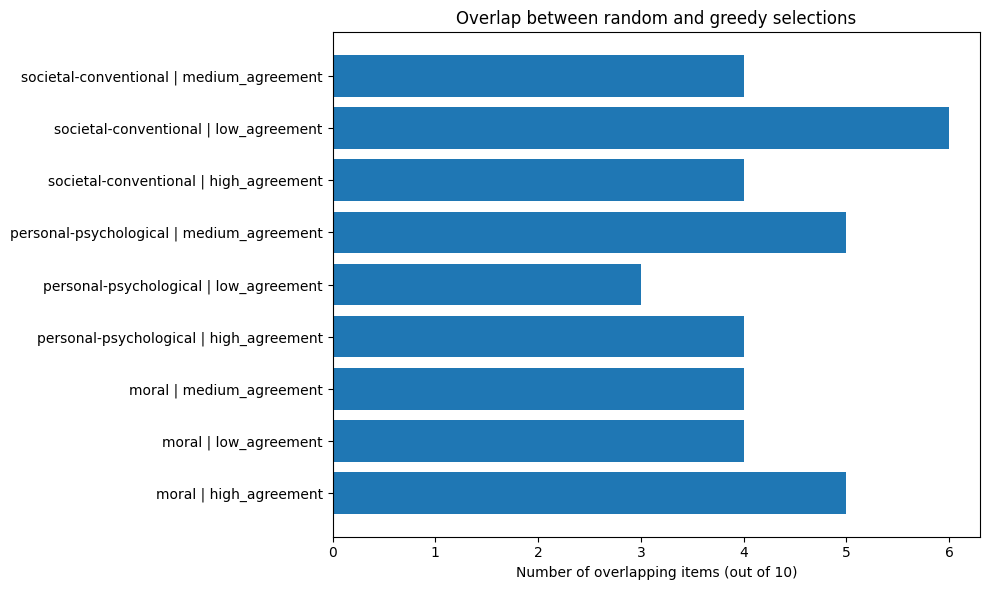

In [11]:
plt.figure(figsize=(10,6))
plt.barh(
    y=comparison["ssl_domain"] + " | " + comparison["agreement_condition"],
    width=comparison["overlap"]
)
plt.xlabel("Number of overlapping items (out of 10)")
plt.title("Overlap between random and greedy selections")
plt.tight_layout()
plt.show()


The overlap between random and greedy selections ranges from 3 to 6 items out of 10. Groups with higher overlap suggest that both methods converge on a similar sense of diversity. Lower overlap indicates that the methods highlight different but still valid subsets. This balance shows that the strategies are not redundant: they can reinforce one another where they agree and broaden coverage where they differ.
